# Function 5

<b> Description of the Sample Application:</b> You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 
Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |
| 05/08/2026 | Week 3 | 1. Added the Week 2 input and output.<br>2. Added RBF vs Matern(nu = 1.5) kernel comparison via log-marginal-likelihood.<br>3. Consolidated GP-fit + acquisition-optimisation into a single reusable bayesian_optimization_step() function.<br>4. Narrowed the search region to delta = 0.2 around the new best point and lowered beta from 1.8 to 1.6.<br>5. Added convergence and parallel-coordinates plots. |
| 11/08/2026 | Week 4 | 1. Recorded the Week 3 output (-1.359780), a sharp drop from Week 2's 1909.163, revealing a cliff rather than a smooth slope.<br>2. Bug Fix: np.log1p(y) is undefined for y <= -1, and Week 3's output is below -1, so the Week 1-3 pipeline would have produced NaNs from this point onward. Replaced it with a signed-log transform that handles negative outputs.<br>3. Added leave-one-out cross-validation (LOO-CV) of the GP to check calibration and overfitting.<br>4. Added an empirical check of whether a small neural network is a viable surrogate at this data size.<br>5. Re-ran the RBF vs Matern comparison post-fix and switched to a bracketed search region spanning the discovered cliff (x2 in [0.596, 0.796]), with x1/x3/x4 kept tight near the boundary. Lowered beta from 1.6 to 1.0. |

## Progress Log

| Week | Query Point (x1, x2, x3, x4) | Output (y) | Best y so far | β (kappa) | Search region | Notes |
|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |
| **Week 1** | 0.037439-0.014236-0.070689-0.986304 | 154.182426 | 1088.860 (unchanged) | 2.5 | full [0, 1)^4 | Deliberately exploratory corner query (high β, sparse 4D coverage). GP had predicted ≈3464.8 in log-space back-transform; true yield was far lower — a sign the RBF surrogate was overconfident extrapolating into an unseen corner. |
| **Week 2** | 0.000000-0.596480-0.999999-0.999999 | 1909.163378 | 1909.163 (New Best) | 1.8 | narrowed box: +-0.25 around Week 1's best | Beat the previous best by ~75%. Predicted mean was 2188.6, which is much closer to the true value than Week 1's miss, showing the narrower box + lower beta improved calibration. || **Week 3** | 0.000000-0.796480-0.999999-0.999999 | -1.359780 | 1909.163 (unchanged) | 1.6 | narrowed box: +/-0.2 around Week 2's best | Predicted mean was +2874.5 - a huge miss. Pushing x2 further in the same direction that worked in Week 2 crashed the output from 1909 to negative, revealing a sharp cliff between x2 = 0.596 and x2 = 0.796, not a smooth slope. This also exposed a pipeline bug (see Change Log) since y < -1 breaks log1p. |
| **Week 4** | - | - | - | 1.0 | bracketed box: x2 in [0.596, 0.796] (spans the cliff); x1, x3, x4 in [0.95-1] tight near boundary except x1 in [0, 0.05] | Fixed the log1p bug with a signed-log transform, re-validated the kernel choice (RBF still wins), added LOO-CV, and checked whether a small neural network is viable yet. Search now deliberately targets the cliff region instead of extrapolating further. ||

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

from plotting_utils import plot_convergence, plot_parallel_coordinates

# Load and Analyse the Data

In [5]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)

In [8]:
# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.037439, 0.014236, 0.070689, 0.986304]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([154.18242633803845]                       , dtype=np.float64)    # from output.txt


# New data from Week 2 submission
X_w2_new_point = np.array([0.      , 0.59648 , 0.999999, 0.999999]     , dtype=np.float64)    # from input.txt
Y_w2_new_point = np.array([1909.163378175112]                          , dtype=np.float64)    # from output.txt

X_w3_new_point = np.array([0.      , 0.79648 , 0.999999, 0.999999]     , dtype=np.float64)    # from input.txt
Y_w3_new_point = np.array([-1.359780271551876]                         , dtype=np.float64)    # from output.txt

In [10]:
# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point
                              , X_w2_new_point
                              , X_w3_new_point                         
                           ))
Y_updated      = np.append(Y0, [Y_w1_new_point
                             , Y_w2_new_point
                             , Y_w3_new_point                          
                              ])


In [12]:
print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.037439   0.014236   0.070689   0.986304  ]
 [0.         

In [14]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: X = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y'] = Y
print("Data Frame:\n", df)


Input  Shape: (23, 4)
Inputs:
 [[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.037439   0.014236   0.070

# Data Exploration

In [17]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3        X_4            Y
count  23.000000  23.000000  23.000000  23.000000    23.000000
mean    0.401964   0.494710   0.505633   0.560030   221.192328
std     0.261562   0.282445   0.290029   0.334524   437.305524
min     0.000000   0.014236   0.070689   0.072880    -1.359780
25%     0.172616   0.255244   0.294025   0.275430    21.362234
50%     0.438350   0.536518   0.479592   0.482088    64.420147
75%     0.630732   0.751737   0.696302   0.864160   193.703018
max     0.836478   0.862540   0.999999   0.999999  1909.163378


In [19]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
X_4    0
Y      0
dtype: int64


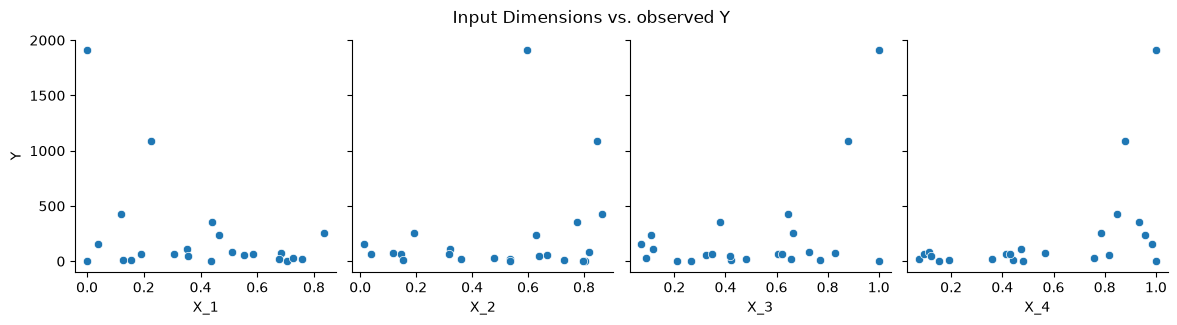

In [21]:
# Pairwise Scatter Plot, showing relationship of y for each input
sns.pairplot(df, y_vars = ['Y'], x_vars = ['X_1', 'X_2', 'X_3', 'X_4'], height = 3)
plt.suptitle("Input Dimensions vs. observed Y", y = 1.05)
plt.show()

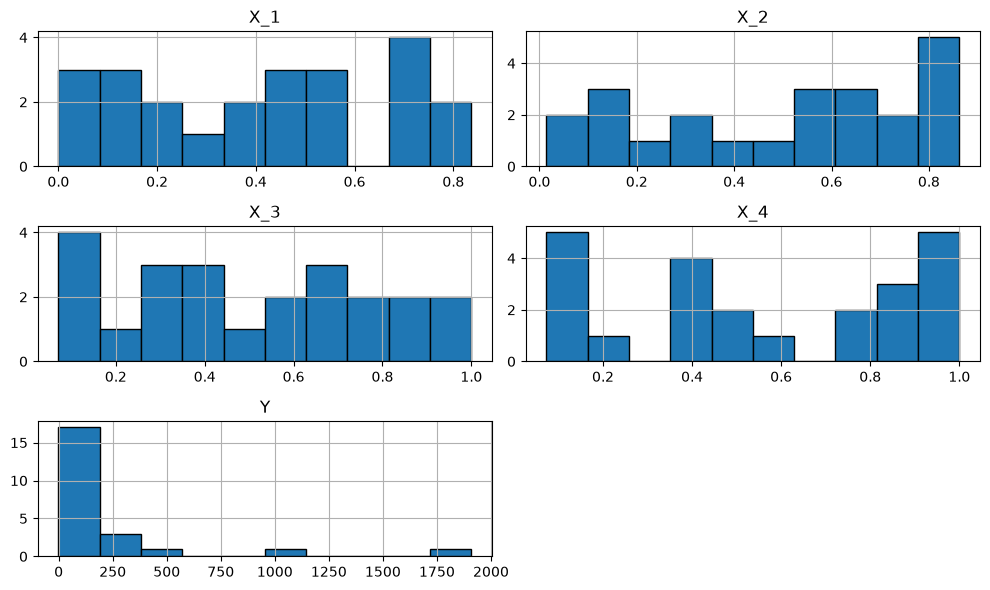

In [23]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [25]:
# Understanding Correlation between each input with y
labels      = ["X_1", "X_2", "X_3", "X_4"]
print("Correlation of each input with Y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i], Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each input with Y:

 corr(X_1, Y) = -0.37974831515908825
 corr(X_2, Y) = 0.2360492657394161
 corr(X_3, Y) = 0.43947864474761983
 corr(X_4, Y) = 0.48130242132697953


<Axes: >

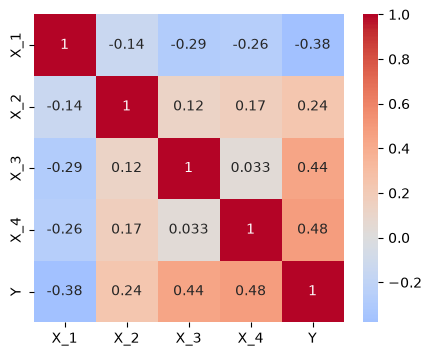

In [27]:
# Plotting the Correlation heatmap
plt.figure(figsize = (5, 4))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm", center = 0)

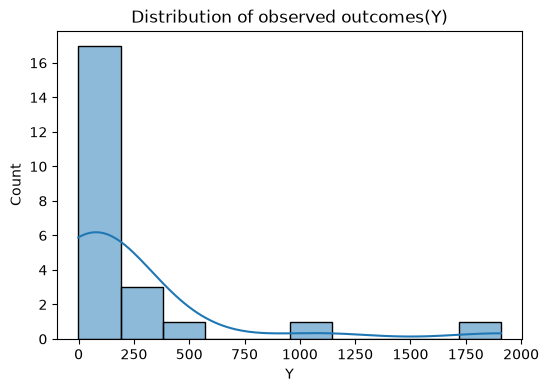

In [29]:
# Plot the Histogram for y to check for Outliers
plt.figure(figsize = (6,4))
sns.histplot(df['Y'], kde = True)
plt.title("Distribution of observed outcomes(Y)")
plt.show()

# Initialize Gaussian Process
Keeping the **RBF** kernel for Week 2 as well, as with only 21 points in 4D the isn't yet enough evidence to justify a rougher kernel like Matern 0.5.
As in Week 1, modelling log1p(Y) rather than raw Y, since the output still spans roughly 3 orders of magnitude (0.11 to ~ 1089) and a plain GP would let the largest values dominate the length-scale/variance fit.ce fit.

In [47]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2)) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = False, n_restarts_optimizer = 10, random_state = 42 )

# Bug Fix ( Week 4 )
Week 3's output was **-1.359780**, which is **below -1**. np.log1p(y) = log(1 + y) is only defined for y > -1; for y <= -1, 1 + y <= 0 and the log is undefined.
Hence, np.log1p(-1.36) returns **NaN**. Since log1p(Y) was modelled since Week 1, this would break the surrogate fit from this point on.

**Fix**: switch to a *signed*-log transform, which compresses large magnitudes the same way log1p did but is defined for the full real line:
```
signed_log1p(y) = sign(y) * log1p( | y | )
inverse         = sign(z) * expm1( | z | )
```
This fix is applied everywhere log1p/expm1 were previously used: the main GP fit below, predict_yield() and inside bayesian_optimization_step().

In [50]:
def signed_log1p(y):
    """Like log1p, but defined for the full real line (handles y <= -1)."""
    return np.sign(y) * np.log1p(np.abs(y))

def inverse_signed_log1p(z):
    """Inverse of signed_log1p."""
    return np.sign(z) * np.expm1(np.abs(z))

# Demonstrate the bug and the fix on Week 3's actual output:
print("Old np.log1p(-1.359780)      :", np.log1p(-1.359780271551876), " <- NaN, this is the bug")
print("New signed_log1p(-1.359780)  :", signed_log1p(-1.359780271551876))
print("Round-trip check             :", inverse_signed_log1p(signed_log1p(-1.359780271551876)))

Old np.log1p(-1.359780)      : nan  <- NaN, this is the bug
New signed_log1p(-1.359780)  : -0.8585685094283249
Round-trip check             : -1.3597802715518763


# Fit the Gaussian Processes to existing data

In [53]:
# y is spread beyond 1000, If we model with raw values of y, couple of large values dominate the Gaussian Processes' length-scale/variance fit
# Hence, modelling  log1p(y) rather than raw y. Working in log-space keeps the regression well-conditioned

X_scaler       = StandardScaler()
X_s            = X_scaler.fit_transform(X)

Y_log          = signed_log1p(Y)       # np.log1p(Y) Bug Fix ( Week 4 )
Y_mean, Y_std  = Y_log.mean(), Y_log.std()
Y_s            = (Y_log - Y_mean) / Y_std

# Train the model

gpr.fit(X_s, Y_s)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  0.911**2 * RBF(length_scale=[100, 0.0387, 100, 100]) + WhiteKernel(noise_level=0.114)


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [55]:
# Function to predict mean and std for raw x
def predict_yield(X_raw):
    Xs          = X_scaler.transform(X_raw)
    mu_s, std_s = gpr.predict(Xs, return_std = True)
    mu_log      = mu_s * Y_std + Y_mean
    std_log     = std_s * Y_std
    #mu_yield    = np.expm1(mu_log)    # Bug Fix ( Week 4 )
    mu_yield    = inverse_signed_log1p(mu_log)
    return mu_yield, std_log

# Setting a higher beta(= 2.5) for Week -1
#beta         = 2.5                

# Setting a higher beta(= 1.8) for Week -8
beta         = 1.8  

# Function to calculare UCB 
def ucb_log_space(X_raw, beta = beta):
    Xs          = X_scaler.transform(X_raw)
    mu_s, std_s = gpr.predict(Xs, return_std = True)
    return mu_s + beta * std_s

# Commented Code for Week 1 
# n_candidates = 200000
# RNG          = np.random.default_rng(42)
# candidates   = RNG.uniform(0, 1, size = (n_candidates, 4))

# ucb_scores   = ucb_log_space(candidates)
# next_idx     = np.argmax(ucb_scores)
# x_next       = candidates[next_idx]

# pred_mu, pred_std_log = predict_yield(x_next.reshape(1, -1))

# print(f"Suggested next Query Point: {x_next}")
# print(f"Predicted Mean(μ): {pred_mu[0]:.6e}")
# print(f"Predicted Std (σ): {pred_std_log[0]:.6e}")
# print(f"UCB Score: {ucb_scores[next_idx]:.6e}")


# Week 2: Consolidated Bayesian Optimisation Function
Define a consolidated function that includes acquisition optimisation into a single reusable function. Two changes from Week 1's approach:

- **Multi-start L-BFGS-B** on the negative UCB, instead of scoring 200,000 random candidates and taking the arg-max. This locates the acquisition optimum more precisely, as the search area becomes smaller.
- The function accepts explicit **bounds**, so it can be reused for the narrowed region this week and for the full `[0,1)^4` cube in earlier/future weeks alike.

In [58]:
def suggest_next_query(gpr, X_scaler, Y_mean, Y_std, bounds, beta = 1.8, n_restarts = 25, seed = 42):
    rng      = np.random.default_rng(seed)
    dim      = bounds.shape[0]

    def neg_acq(x):
        x           = x.reshape(1, -1)
        Xs          = X_scaler.transform(x)
        mu_s, std_s = gpr.predict(Xs, return_std = True)
        return -(mu_s[0] + beta * std_s[0])

    best_val, best_x = np.inf, None
    starts           = rng.uniform(bounds[:, 0], bounds[:, 1], size = (n_restarts, dim))
    for x0 in starts:
        res          = minimize(neg_acq, x0, bounds = list(zip(bounds[:, 0], bounds[:, 1])), method = "L-BFGS-B")
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, std_next = predict_yield(best_x.reshape(1, -1))
    return best_x, mu_next[0], std_next[0], -best_val


# Narrow the search region and run the Week 2 query


In [61]:
# Restricting the candidate search to a box of half-width **0.25** around the current best point.
delta      = 0.25
best_x_now = X[best_idx]

lb         = np.clip(best_x_now - delta, 0.0, 0.999999)
ub         = np.clip(best_x_now + delta, 0.0, 0.999999)
bounds     = np.vstack([lb, ub]).T
print("Narrowed search bounds (per dimension):\n", bounds)

x_next, pred_mu, pred_std_log, ucb_next = suggest_next_query(gpr, X_scaler, Y_mean, Y_std, bounds, beta = beta)

print(f"\nSuggested next Query Point: {np.round(x_next, 6)}")
print(f"Predicted Mean (μ)          : {pred_mu:.4f}")
print(f"Predicted Std (σ, log-space): {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

Narrowed search bounds (per dimension):
 [[0.       0.25    ]
 [0.34648  0.84648 ]
 [0.749999 0.999999]
 [0.749999 0.999999]]

Suggested next Query Point: [0.04032  0.60434  0.788067 0.924077]
Predicted Mean (μ)          : 651.7879
Predicted Std (σ, log-space): 1.4031
UCB Score                   : 2.5711


# Perform Visualisation ( Week 1 )

Full 4D UCB surface can't be drawn directly. Hence, we visualise 2D slices for every pair of dimensions, fix the other two dimensions at the current
best-known x, and sweep a grid over the chosen pair. This shows how UCB (and mu, sigma) behave locally around the best point found so far.

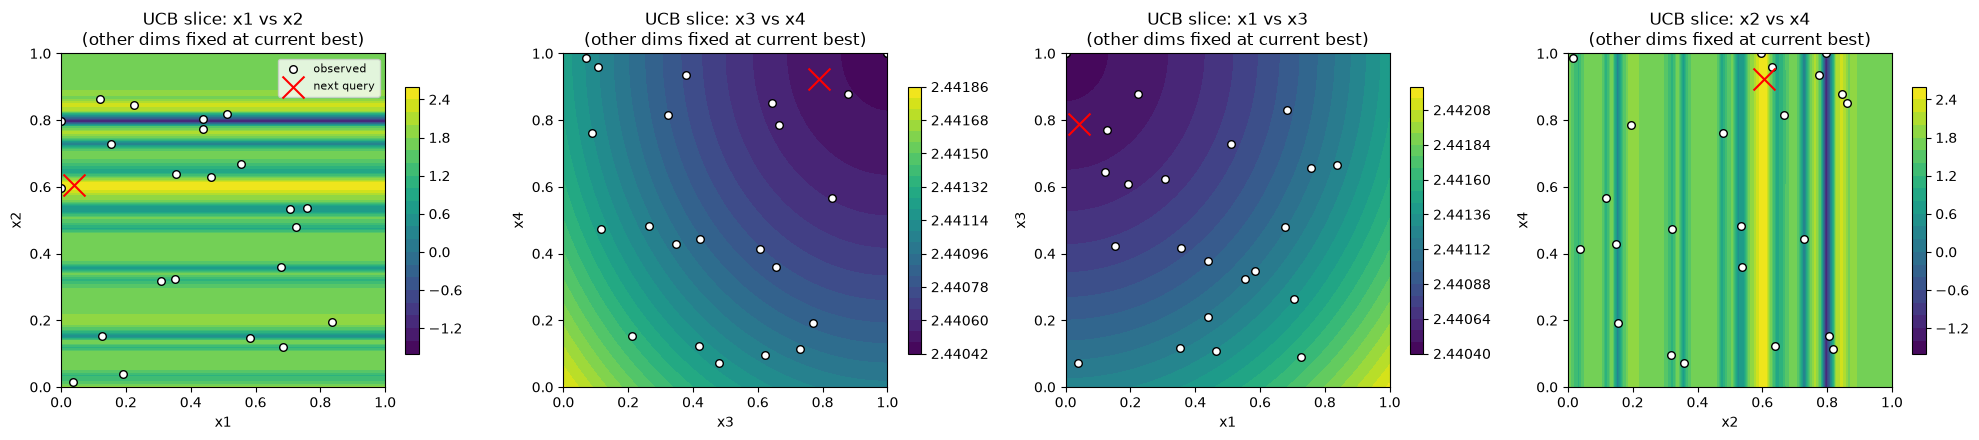

In [65]:
grid_n = 60
grid_1d = np.linspace(0, 1, grid_n)
pairs = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point = X[best_idx].copy()  # anchor the other two dims here
 
fig, axes = plt.subplots(1, len(pairs), figsize=(5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    A, B = np.meshgrid(grid_1d, grid_1d)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()
 
    scores = ucb_log_space(grid_points).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels=25, cmap="viridis")
    ax.scatter(X[:, d1], X[:, d2], c="white", edgecolor="black", s=30, label="observed")
    ax.scatter(x_next[d1], x_next[d2], c="red", marker="x", s=250, label="next query")
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice: x{d1+1} vs x{d2+1}\n(other dims fixed at current best)")
    fig.colorbar(im, ax=ax, shrink=0.8)
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()

# Week 2: UCB Visualisation ( Zoomed to the narrowed region )
This week zoomed into the narrowed box rather than the full unit cube, so the local structure around the current best is visible in more detail.l.

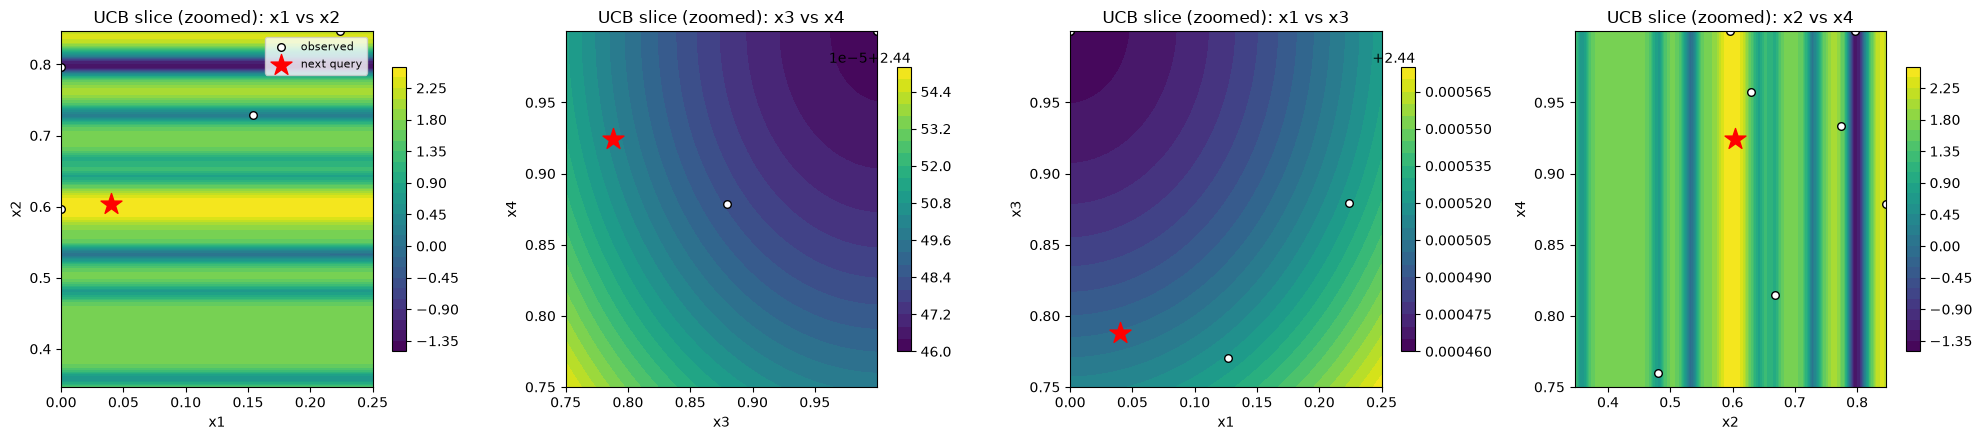

In [68]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc="upper right", fontsize = 8)
plt.tight_layout()
plt.show()


# Week 3: Kernel Comparison ( RBF vs Matern )

In [71]:
# Week 3: Kernel Comparison
gpr_rbf       = gpr   

kernel_matern = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * 4, length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                  + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))

gpr_matern = GaussianProcessRegressor(kernel = kernel_matern, normalize_y = False, n_restarts_optimizer = 10, random_state = 42)
gpr_matern.fit(X_s, Y_s)

lml_rbf    = gpr_rbf.log_marginal_likelihood(gpr_rbf.kernel_.theta)
lml_matern = gpr_matern.log_marginal_likelihood(gpr_matern.kernel_.theta)

print(f"RBF    kernel            : {gpr_rbf.kernel_}")
print(f"  Log-marginal-likelihood: {lml_rbf:.3f}")
print(f"Matern kernel            : {gpr_matern.kernel_}")
print(f"  Log-marginal-likelihood: {lml_matern:.3f}")

# Keep whichever kernel fits the data better (Choose kernel with igher log-marginal-likelihood)
if lml_matern > lml_rbf:
    gpr           = gpr_matern
    chosen_kernel = "Matern(nu=1.5)"
else:
    gpr           = gpr_rbf
    chosen_kernel = "RBF"

print(f"\nWeek 3 kernel choice: {chosen_kernel} (Choose kernel with higher log-marginal-likelihood )")


RBF    kernel            : 0.911**2 * RBF(length_scale=[100, 0.0387, 100, 100]) + WhiteKernel(noise_level=0.114)
  Log-marginal-likelihood: -29.769
Matern kernel            : 0.923**2 * Matern(length_scale=[100, 0.0412, 100, 100], nu=1.5) + WhiteKernel(noise_level=0.0934)
  Log-marginal-likelihood: -30.149

Week 3 kernel choice: RBF (Choose kernel with higher log-marginal-likelihood )


# Week 3: Consolidated Bayesian Optimisation Function

In [73]:
def bayesian_optimization_step(X, Y, bounds, beta = 1.6, kernel_type = "rbf", n_restarts_gp = 10, n_restarts_acq = 25, seed = 42):
    X_scaler_l = StandardScaler()
    X_s_l      = X_scaler_l.fit_transform(X)
    #Y_log_l    = np.log1p(Y)     # Commented for Bug Fix ( Week 4 )
    Y_log_l    = signed_log1p(Y)  # Added for Week 4 Bug Fix
    Y_mean_l, Y_std_l = Y_log_l.mean(), Y_log_l.std()
    Y_s_l      = (Y_log_l - Y_mean_l) / Y_std_l

    if kernel_type == "rbf":
        kernel_l = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [1.0] * X.shape[1], length_scale_bounds = (1e-2, 1e2)) \
                   + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
    elif kernel_type == "matern":
        kernel_l = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * X.shape[1], length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                   + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
    else:
        raise ValueError("kernel_type must be 'rbf' or 'matern'")

    gpr_l = GaussianProcessRegressor(kernel = kernel_l, normalize_y = False, n_restarts_optimizer = n_restarts_gp, random_state = seed)
    gpr_l.fit(X_s_l, Y_s_l)
    lml_l = gpr_l.log_marginal_likelihood(gpr_l.kernel_.theta)

    def predict_yield_l(X_raw):
        Xs = X_scaler_l.transform(X_raw)
        mu_s, std_s = gpr_l.predict(Xs, return_std = True)
        mu_log      = mu_s * Y_std_l + Y_mean_l
        std_log     = std_s * Y_std_l
        #return np.expm1(mu_log), std_log              # Commented for Bug Fix ( Week 4 )
        return inverse_signed_log1p(mu_log), std_log   # Added for Bug Fix ( Week 4 )

    rng = np.random.default_rng(seed)
    dim = bounds.shape[0]

    def neg_acq(x):
        x = x.reshape(1, -1)
        Xs = X_scaler_l.transform(x)
        mu_s, std_s = gpr_l.predict(Xs, return_std = True)
        return -(mu_s[0] + beta * std_s[0])

    best_val, best_x = np.inf, None
    starts = rng.uniform(bounds[:, 0], bounds[:, 1], size = (n_restarts_acq, dim))
    for x0 in starts:
        res = minimize(neg_acq, x0, bounds = list(zip(bounds[:, 0], bounds[:, 1])), method = "L-BFGS-B")
        if res.fun < best_val:
            best_val, best_x = res.fun, res.x

    mu_next, std_next = predict_yield_l(best_x.reshape(1, -1))

    return {
        "kernel_type": kernel_type, "gpr": gpr_l, "X_scaler": X_scaler_l,
        "Y_mean": Y_mean_l, "Y_std": Y_std_l, "log_marginal_likelihood": lml_l,
        "x_next": best_x, "mu_next": mu_next[0], "std_next": std_next[0],
        "ucb_next": -best_val,
    }

# --- Narrow the search region around the CURRENT best (now Week 2's point) ---
delta      = 0.2                                     # Week 3 delta reduced from 0.25 to 0.2
best_idx   = np.argmax(Y)                            # recompute in case data changed above
best_x_now = X[best_idx]

lb         = np.clip(best_x_now - delta, 0.0, 0.999999)
ub         = np.clip(best_x_now + delta, 0.0, 0.999999)
bounds     = np.vstack([lb, ub]).T
print("Week 3 narrowed search bounds (per dimension):\n", bounds)

beta = 1.6                                           # Week 3: beta reduced from 1.8 to 1.6 to facilitate exploitation

# Check Kernel best-fit
result_rbf    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")

print(f"bayesian_optimization_step RBF LML     : {result_rbf['log_marginal_likelihood']:.3f}")
print(f"bayesian_optimization_step Matern LML  : {result_matern['log_marginal_likelihood']:.3f}")

final = result_matern if result_matern["log_marginal_likelihood"] > result_rbf["log_marginal_likelihood"] else result_rbf


gpr             = final["gpr"]
X_scaler        = final["X_scaler"]
Y_mean          = final["Y_mean"]
Y_std           = final["Y_std"]
x_next          = final["x_next"]
pred_mu         = final["mu_next"]
pred_std_log    = final["std_next"]
ucb_next        = final["ucb_next"]

print(f"\nWeek 3 chosen kernel      : {final['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

Week 3 narrowed search bounds (per dimension):
 [[0.       0.2     ]
 [0.39648  0.79648 ]
 [0.799999 0.999999]
 [0.799999 0.999999]]
bayesian_optimization_step RBF LML     : -29.769
bayesian_optimization_step Matern LML  : -30.149

Week 3 chosen kernel      : rbf
Suggested next Query Point  : [0.08914  0.6033   0.86042  0.926089]
Predicted Mean (mu)         : 751.4061
Predicted Std (sigma, log)  : 1.3194
UCB Score                   : 2.4316


# Week 3: UCB Visualisation

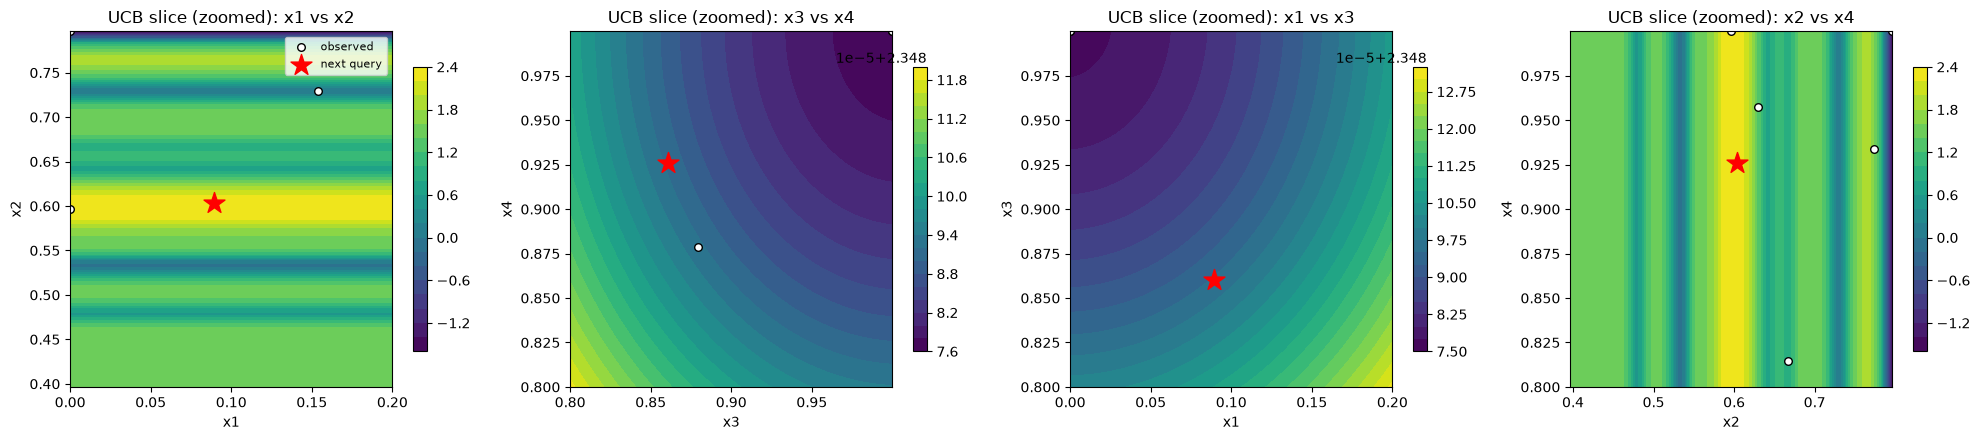

In [76]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()


# Week 4: Implementing LOO cross-validation and a bracketed search around the discovered cliff

In [84]:
# Leave-one-out cross-validation of the GP 
def loo_cv_gp(X, Y, kernel_type = "rbf", seed = 42):
    n                = len(Y)
    residuals, in_ci = [], []
    for i in range(n):
        mask             = np.ones(n, dtype = bool)
        mask[i]          = False
        X_train, Y_train = X[mask], Y[mask]
        X_test, Y_test   = X[i:i+1], Y[i]

        Xsc              = StandardScaler()
        Xs_tr            = Xsc.fit_transform(X_train)
        Ylog_tr          = signed_log1p(Y_train)
        ymean_l, ystd_l  = Ylog_tr.mean(), Ylog_tr.std()
        Ys_tr            = (Ylog_tr - ymean_l) / ystd_l

        if kernel_type == "rbf":
            k            = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [1.0] * X.shape[1], length_scale_bounds = (1e-2, 1e2)) \
                             + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))
        else:
            k            = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [1.0] * X.shape[1], length_scale_bounds = (1e-2, 1e2), nu = 1.5) \
                + WhiteKernel(noise_level = 1e-2, noise_level_bounds = (1e-5, 1e0))

        g                = GaussianProcessRegressor(kernel = k, normalize_y = False, n_restarts_optimizer = 3, random_state = seed)
        g.fit(Xs_tr, Ys_tr)

        mu_s, std_s      = g.predict(Xsc.transform(X_test), return_std = True)
        mu_log           = mu_s[0] * ystd_l + ymean_l
        std_log          = std_s[0] * ystd_l
        mu_pred          = inverse_signed_log1p(mu_log)

        residuals.append(Y_test - mu_pred)
        half_width       = abs(inverse_signed_log1p(mu_log + std_log) - mu_pred)
        in_ci.append(mu_pred - 1.96*half_width <= Y_test <= mu_pred + 1.96 * half_width)

    residuals            = np.array(residuals)
    rmse                 = np.sqrt(np.mean(residuals**2))
    coverage             = np.mean(in_ci)
    return rmse, coverage, residuals

rmse_gp, coverage_gp, resid_gp = loo_cv_gp(X, Y, kernel_type = "rbf")
print(f"GP  LOO-CV RMSE               : {rmse_gp:.3f}")
print(f"GP  LOO-CV 95% CI coverage   : {coverage_gp*100:.1f}%  (target 95%)")

# Checking if a Neural Network applicable could be a fit
def loo_cv_mlp(X, Y, seed = 42):
    n           = len(Y)
    residuals   = []
    for i in range(n):
        mask    = np.ones(n, dtype = bool)
        mask[i] = False
        X_train, Y_train = X[mask], Y[mask]
        X_test, Y_test   = X[i:i+1], Y[i]

        Xsc    = StandardScaler()
        Xs_tr = Xsc.fit_transform(X_train)
        Ylog_tr = signed_log1p(Y_train)
        ymean_l, ystd_l = Ylog_tr.mean(), Ylog_tr.std()
        Ys_tr = (Ylog_tr - ymean_l) / ystd_l

        mlp = MLPRegressor(hidden_layer_sizes = (8,), max_iter = 5000, random_state = seed)
        mlp.fit(Xs_tr, Ys_tr)

        pred_s  = mlp.predict(Xsc.transform(X_test))[0]
        mu_log  = pred_s * ystd_l + ymean_l
        mu_pred = inverse_signed_log1p(mu_log)
        residuals.append(Y_test - mu_pred)
    residuals = np.array(residuals)
    return np.sqrt(np.mean(residuals**2)), residuals

rmse_mlp, resid_mlp = loo_cv_mlp(X, Y)
print(f"\nMLP (small NN) LOO-CV RMSE    : {rmse_mlp:.3f}")
print(f"GP             LOO-CV RMSE    : {rmse_gp:.3f}")
winner = "GP" if rmse_gp < rmse_mlp else "MLP"
print(f"-> {winner} generalises better at n={len(Y)} points -- confirms the GP is still the right surrogate for now.")

# Bracket the discovered cliff along x2, hence keeping x1/x3/x4 tight near the boundary
good_pt = X_w2_new_point   # x2=0.596 -> 1909.16
bad_pt  = X_w3_new_point   # x2=0.796 -> -1.36

lb = np.array([0.0 , min(good_pt[1], bad_pt[1]), 0.95, 0.95])
ub = np.array([0.05, max(good_pt[1], bad_pt[1]), 0.999999, 0.999999])
bounds = np.vstack([lb, ub]).T
print("\nWeek 4 bracketed search bounds (per dimension):\n", bounds)

beta = 1.0   # WEEK 4 CHANGE: 1.6 -> 1.0 (favour precise localisation of the cliff over broad exploration)

result_rbf_w4    = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "rbf")
result_matern_w4 = bayesian_optimization_step(X, Y, bounds, beta = beta, kernel_type = "matern")
print(f"\nWeek 4 RBF    LML: {result_rbf_w4['log_marginal_likelihood']:.3f}")
print(f"Week 4 Matern LML: {result_matern_w4['log_marginal_likelihood']:.3f}")

final_w4 = result_matern_w4 if result_matern_w4["log_marginal_likelihood"] > result_rbf_w4["log_marginal_likelihood"] else result_rbf_w4

gpr             = final_w4["gpr"]
X_scaler        = final_w4["X_scaler"]
Y_mean          = final_w4["Y_mean"]
Y_std           = final_w4["Y_std"]
x_next          = final_w4["x_next"]
pred_mu         = final_w4["mu_next"]
pred_std_log    = final_w4["std_next"]
ucb_next        = final_w4["ucb_next"]

print(f"\nWeek 4 chosen kernel        : {final_w4['kernel_type']}")
print(f"Suggested next Query Point  : {np.round(x_next, 6)}")
print(f"Predicted Mean (mu)         : {pred_mu:.4f}")
print(f"Predicted Std (sigma, log)  : {pred_std_log:.4f}")
print(f"UCB Score                   : {ucb_next:.4f}")

GP  LOO-CV RMSE               : 765.953
GP  LOO-CV 95% CI coverage   : 82.6%  (target 95%)

MLP (small NN) LOO-CV RMSE    : 31139.566
GP             LOO-CV RMSE    : 765.953
-> GP generalises better at n=23 points -- confirms the GP is still the right surrogate for now.

Week 4 bracketed search bounds (per dimension):
 [[0.       0.05    ]
 [0.59648  0.79648 ]
 [0.95     0.999999]
 [0.95     0.999999]]

Week 4 RBF    LML: -29.769
Week 4 Matern LML: -30.149

Week 4 chosen kernel        : rbf
Suggested next Query Point  : [0.018201 0.598992 0.955729 0.998108]
Predicted Mean (mu)         : 1160.0569
Predicted Std (sigma, log)  : 0.9817
UCB Score                   : 2.0756


# Week 4: UCB Visualisation (bracketed search region)

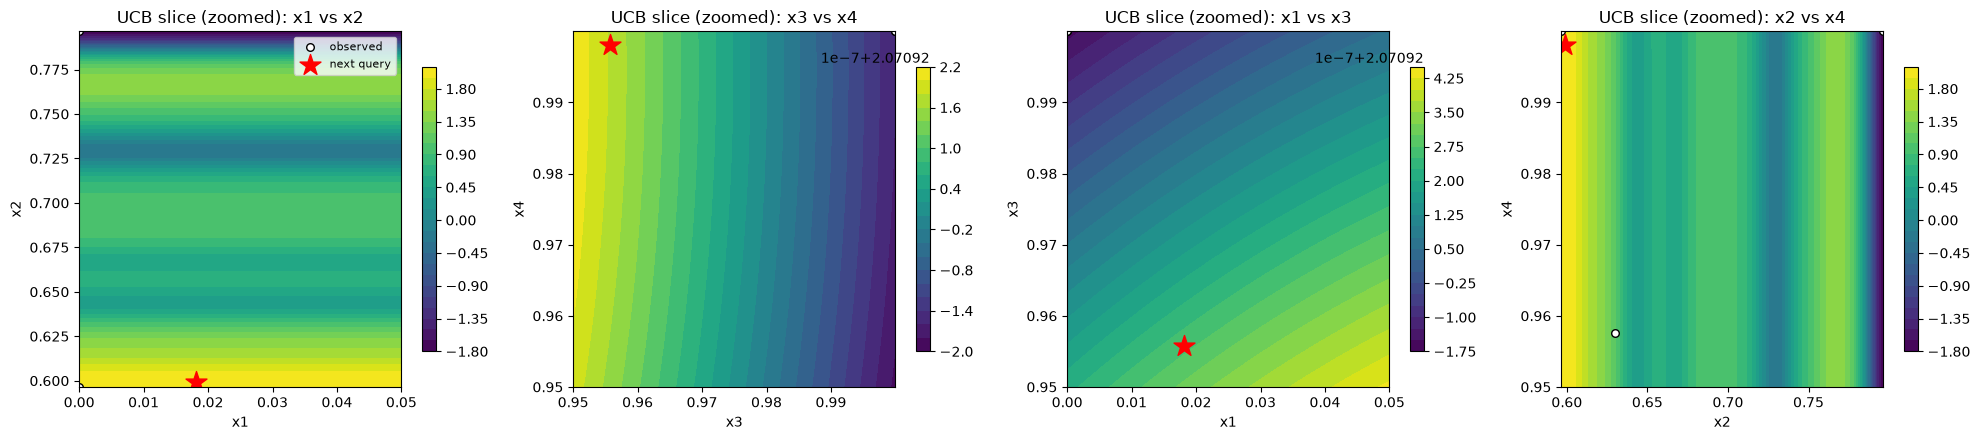

In [88]:
grid_n          = 60
pairs           = [(0, 1), (2, 3), (0, 2), (1, 3)]
fixed_point     = best_x_now.copy()

fig, axes       = plt.subplots(1, len(pairs), figsize = (5 * len(pairs), 4.5))
for ax, (d1, d2) in zip(axes, pairs):
    g1          = np.linspace(bounds[d1, 0], bounds[d1, 1], grid_n)
    g2          = np.linspace(bounds[d2, 0], bounds[d2, 1], grid_n)
    A, B        = np.meshgrid(g1, g2)
    grid_points = np.tile(fixed_point, (grid_n * grid_n, 1))
    grid_points[:, d1] = A.ravel()
    grid_points[:, d2] = B.ravel()

    scores = ucb_log_space(grid_points, beta).reshape(grid_n, grid_n)
    im = ax.contourf(A, B, scores, levels = 25, cmap = "viridis")
    ax.scatter(X[:, d1], X[:, d2], c = "white", edgecolor = "black", s = 30, label = "observed")
    ax.scatter(x_next[d1], x_next[d2], c = "red", marker = "*", s = 250, label = "next query")
    ax.set_xlim(bounds[d1, 0], bounds[d1, 1])
    ax.set_ylim(bounds[d2, 0], bounds[d2, 1])
    ax.set_xlabel(f"x{d1+1}")
    ax.set_ylabel(f"x{d2+1}")
    ax.set_title(f"UCB slice (zoomed): x{d1+1} vs x{d2+1}")
    fig.colorbar(im, ax = ax, shrink = 0.8)
axes[0].legend(loc = "upper right", fontsize = 8)
plt.tight_layout()
plt.show()

# Portal Submission 

In [90]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
def format_submission(x):
    return "-".join(f"{v:.6f}" for v in x)

submission_str = format_submission(x_next)
print("Points to be submitted(Week 1):",'0.037439-0.014236-0.070689-0.986304')
print("Points to be submitted(Week 2):",'0.000000-0.596480-0.999999-0.999999')
print("Points to be submitted(Week 3):",'0.000000-0.796480-0.999999-0.999999')
print(f"Points to be submitted(Week 4): {submission_str}")

Points to be submitted(Week 1): 0.037439-0.014236-0.070689-0.986304
Points to be submitted(Week 2): 0.000000-0.596480-0.999999-0.999999
Points to be submitted(Week 3): 0.000000-0.796480-0.999999-0.999999
Points to be submitted(Week 4): 0.018201-0.598992-0.955729-0.998108


# Convergence & parallel-coordinates plots

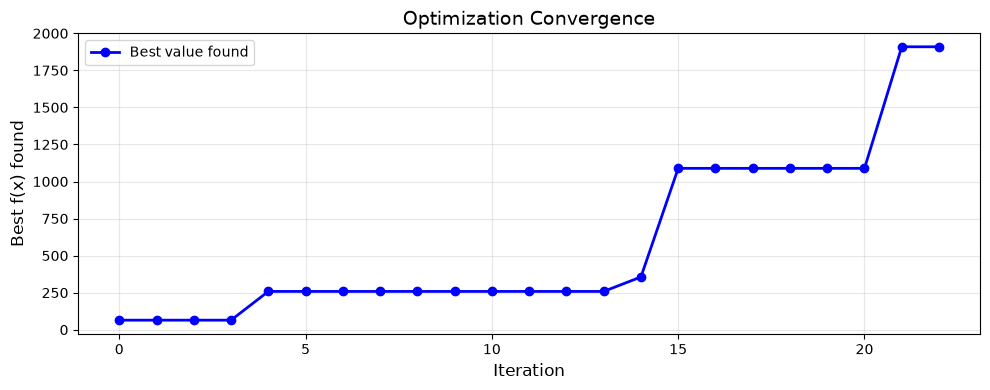

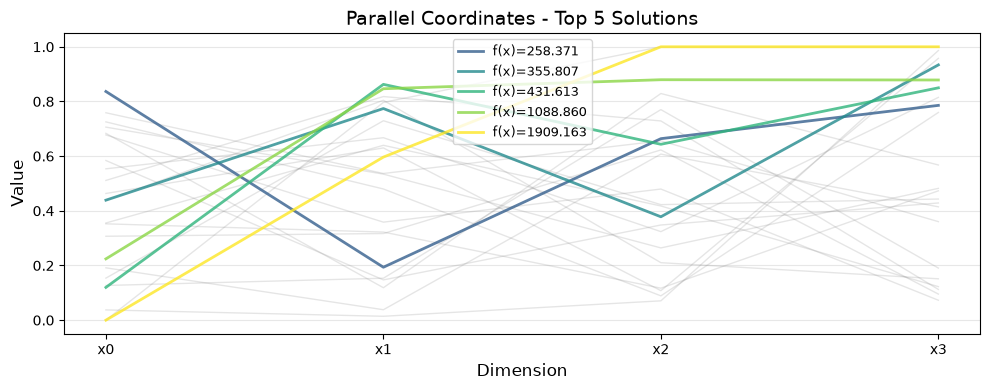

In [93]:
best_so_far   = []
running_best  = -np.inf
for val in Y:
    running_best = max(running_best, val)
    best_so_far.append(running_best)

plot_convergence(range(len(best_so_far)), best_so_far)
plt.show()

plot_parallel_coordinates(X, Y, n_best = 5)
plt.show()